
# Multi-Agent Biography Debate Reproduction

This notebook reproduces the paper:

**Improving Factuality and Reasoning in Language Models through Multiagent Debate**

Paper:
https://composable-models.github.io/llm_debate/

The notebook:
1. Loads biography dataset
2. Processes data
3. Runs multi-agent debate inference
4. Evaluates generated biographies
5. Saves results


In [2]:
import json
import random
import time
import numpy as np
from tqdm import tqdm
import requests
import matplotlib.pyplot as plt


# Configuration

Configure:
- Local Ollama API
- Debate models
- Debate rounds
- Output files


In [18]:
# Local Ollama configuration
OLLAMA_API_URL = "http://localhost:11434/api/generate"

# Debate models running locally under Ollama
MODELS = [
    "deepseek-r1:1.5b",
    # "gemma4:e2b",
    "llama3.2:latest",
]

# Debate settings
ROUNDS = 2
DATASET_SIZE = 100

# Output files
OUTPUT_FILE = "biography_debate_results2.json"
EVAL_OUTPUT_FILE = "biography_evaluation_results2.json"

print("Using local Ollama endpoint:", OLLAMA_API_URL)
print("Models:", MODELS)


Using local Ollama endpoint: http://localhost:11434/api/generate
Models: ['deepseek-r1:1.5b', 'llama3.2:latest']



# Load Biography Dataset

Load the original biography dataset from `article.json`.

Dataset format:
```json
{
    "Alan Turing": "...",
    "Ada Lovelace": "..."
}
```


In [19]:

with open("articles.json", "r") as f:
    data = json.load(f)

print("Dataset loaded successfully")
print(f"Total records: {len(data)}")


next(iter(data.values()), "No value found")

Dataset loaded successfully
Total records: 524


"- Aaron Sloman is a philosopher and researcher on artificial intelligence and cognitive science\n- He held the Chair in Artificial Intelligence and Cognitive Science at the School of Computer Science at the University of Birmingham and previously at the University of Sussex\n- Sloman has published widely on philosophy of mathematics, epistemology, cognitive science, and artificial intelligence and collaborated with biologist Jackie Chappell on the evolution of intelligence\n- He was born in Southern Rhodesia (now Zimbabwe) to Lithuanian Jewish parents, and went to school in Cape Town before earning a degree in Mathematics and Physics at the University of Cape Town and a DPhil in philosophy at the University of Oxford\n- Sloman's philosophical ideas were influenced by Immanuel Kant, Gottlob Frege, Karl Popper and others, and his work in AI by Marvin Minsky and John McCarthy\n- He is a Fellow of several AI and philosophy associations and received the K. Jon Barwise Prize for contributio


# Data Processing

This section:
- Cleans people names
- Parses bullet points
- Prepares the dataset for debate

The original paper removes extra text inside parentheses.


In [20]:

def filter_people(person):
    '''
    Remove text inside parentheses, e.g., Adele Goldberg (computer scientist) > Adele Goldberg.
    '''

    return person.split("(")[0].strip()


def parse_bullets(text):
    '''
    Convert text into bullet points.
    '''

    bullets = []

    for line in text.split("\n"):

        line = line.strip()

        if line:
            bullets.append(line)

    return bullets


# Extract people names
people = sorted(data.keys())

print("Old Data")
print(people[:5])

# Clean names
people = [filter_people(person) for person in people]

# Shuffle for reproducibility
random.seed(0)
random.shuffle(people)

print("\nClean Data:")
print(people[:5])


Old Data
['Aaron Sloman', 'Abhay Bhushan', 'Adam Dunkels', 'Adele Goldberg (computer scientist)', 'Adi Shamir']

Clean Data:
['Shakuntala Atre', 'Butler Lampson', 'Luca Cardelli', 'Philip Don Estridge', 'Gillian Lovegrove']



# Debate Prompt Construction

This function:
- Collects responses from other agents
- Builds debate feedback prompts
- Encourages refinement and factual correction


In [21]:

def construct_message(agent_contexts, current_agent_idx, response_idx, person):

    prompt = (
        f"Here are biographies of {person} "
        f"generated by other agents:\n"
    )

    # Collect responses from other agents
    for i, context in enumerate(agent_contexts):

        if i != current_agent_idx:

            response = context[response_idx]["content"]

            prompt += (
                f"\nAgent {i} Biography:\n"
                f"{response}\n"
            )

    # Debate instruction
    prompt += (
        f"\nReview the other biographies carefully. "
        f"Correct mistakes, improve factual accuracy, "
        f"and generate a better biography of {person}."
    )

    return {
        "role": "user",
        "content": prompt
    }



# Model Inference Function

This function sends prompts to the selected model and returns the generated response.


In [22]:

def make_prompt_from_messages(messages):
    prompt_lines = []
    for message in messages:
        role = message.get("role", "user")
        content = message.get("content", "")
        prompt_lines.append(f"[{role}] {content}")
    return "\n\n".join(prompt_lines)


def generate_answer(messages, model):
    prompt = make_prompt_from_messages(messages)
    response = requests.post(
        OLLAMA_API_URL,
        json={
            "model": model,
            "prompt": prompt,
            "stream": False,
        },
        timeout=120,
    )
    response.raise_for_status()
    result = response.json()

    if isinstance(result, dict) and "response" in result:
        return result["response"]

    return str(result)


# Run Multi-Agent Debate

Pipeline:
1. Each agent generates a biography
2. Agents review other responses
3. Debate rounds refine biographies
4. Final responses are stored

Intermediate outputs are printed to understand the full debate process.


In [23]:

generated_biographies = {}

print("Starting Multi-Agent Debate...")

start_time = time.time()

# Process people one by one
for person in tqdm(people[:DATASET_SIZE]):

    print(f"\nPROCESSING: {person} -----------------------")

    # Initial prompt for all agents
    agent_contexts = [
        [
            {
                "role": "user",
                "content": (
                    f"Give a bullet point biography of {person}. "
                    f"Highlight their contributions and achievements "
                    f"in computer science."
                )
            }
        ]
        for _ in range(len(MODELS))
    ]

    # Debate rounds
    for r in range(ROUNDS):

        for i in range(len(MODELS)):
            print(f"ROUND {r+1} --- Model: {i}: {MODELS[i]}")

            # Add debate feedback after first round
            if r != 0:

                debate_message = construct_message(
                    agent_contexts,
                    i,
                    2*r - 1,
                    person
                )

                agent_contexts[i].append(debate_message)

            # Generate biography
            try:
                content = generate_answer(
                    agent_contexts[i],
                    MODELS[i]
                )
            except Exception as e:
                print("API Error:", e)
                time.sleep(5)
                break

            # Save assistant response
            agent_contexts[i].append({
                "role": "assistant",
                "content": content
            })

            # Parse bullet points
            bullets = parse_bullets(content)

    # Store results
    generated_biographies[person] = agent_contexts

end_time = time.time()
print(f"\nTotal Time: {(end_time - start_time) / 60:.2f} mins")

Starting Multi-Agent Debate...


  0%|                                                                   | 0/100 [00:00<?, ?it/s]


PROCESSING: Shakuntala Atre -----------------------
ROUND 1 --- Model: 0: deepseek-r1:1.5b
ROUND 1 --- Model: 1: llama3.2:latest
ROUND 2 --- Model: 0: deepseek-r1:1.5b
ROUND 2 --- Model: 1: llama3.2:latest


  1%|▌                                                        | 1/100 [00:57<1:35:29, 57.87s/it]


PROCESSING: Butler Lampson -----------------------
ROUND 1 --- Model: 0: deepseek-r1:1.5b
ROUND 1 --- Model: 1: llama3.2:latest
ROUND 2 --- Model: 0: deepseek-r1:1.5b
ROUND 2 --- Model: 1: llama3.2:latest


...


PROCESSING: Alston Householder -----------------------
ROUND 1 --- Model: 0: deepseek-r1:1.5b
ROUND 1 --- Model: 1: llama3.2:latest
ROUND 2 --- Model: 0: deepseek-r1:1.5b
ROUND 2 --- Model: 1: llama3.2:latest


 99%|██████████████████████████████████████████████████████▍| 99/100 [2:39:07<01:45, 105.31s/it]


PROCESSING: Danese Cooper -----------------------
ROUND 1 --- Model: 0: deepseek-r1:1.5b
ROUND 1 --- Model: 1: llama3.2:latest
ROUND 2 --- Model: 0: deepseek-r1:1.5b
ROUND 2 --- Model: 1: llama3.2:latest


100%|███████████████████████████████████████████████████████| 100/100 [2:40:31<00:00, 96.31s/it]


Total Time: 160.52 mins



# Save Results

Save all debate histories and generated biographies into a JSON file.


In [24]:

with open(OUTPUT_FILE, "w") as f:
    json.dump(generated_biographies, f, indent=4)

print("Results saved successfully")
print("Saved to:", OUTPUT_FILE)


Results saved successfully
Saved to: biography_debate_results2.json


# Run Evaluation

Evaluation process:
1. Load ground truth biography
2. Extract facts
3. Compare generated biography against each fact
4. Use an LLM judge to evaluate factual consistency
5. Compute accuracy

This evaluation uses a local Ollama model.

Requirements:
1. Install Ollama
2. Pull a model

Example:
    ollama pull llama3

Run Ollama locally before executing evaluation.


In [25]:

OLLAMA_URL = "http://localhost:11434/api/generate"
JUDGE_MODEL = "deepseek-r1:1.5b"  # Local judge model


print("Using local Ollama judge model:", JUDGE_MODEL)


Using local Ollama judge model: deepseek-r1:1.5b


In [26]:

def parse_yes_no(string):

    string = string.lower()

    if "uncertain" in string:
        return None

    elif "yes" in string:
        return True

    elif "no" in string:
        return False

    return None


In [27]:

def evaluate_with_ollama(prompt):
    """
    Send evaluation prompt to local Ollama model.
    """

    response = requests.post(
        OLLAMA_URL,
        json={
            "model": JUDGE_MODEL,
            "prompt": prompt,
            "stream": False
        }
    )

    return response.json()["response"]

In [28]:
print("Starting Local Evaluation...")

evaluation_records = []
accuracies_by_stage = {
    "single": [],
    "debate": []
}

# Ground truth preprocessing
gt_data_filter = {}
for k, v in data.items():
    k = filter_people(k)
    gt_data_filter[k] = v

gt_data = gt_data_filter

# ==================================================
# EVALUATE GENERATED BIOGRAPHIES
# ==================================================
start_time = time.time()

for person in generated_biographies.keys():
    if person not in gt_data:
        continue

    print(f"\nEVALUATING: {person} -----------------")

    gt_description = gt_data[person]
    gt_bullets = parse_bullets(gt_description)

    bio_descriptions = generated_biographies[person]

    for idx, description in enumerate(bio_descriptions):
        print(f"Agent: {idx}")

        stages = {}
        if len(description) > 1:
            stages["single"] = description[1]["content"]
        if len(description) > 0:
            stages["debate"] = description[-1]["content"]

        for stage, bio_description in stages.items():
            bio_bullets = parse_bullets(bio_description)
            if len(bio_bullets) == 1 and len(bio_bullets[0]) < 400:
                continue

            bio_bullets_text = " ".join(bio_bullets)

            for bullet in gt_bullets:
                prompt = f"""
                    You are evaluating factual consistency.
                    
                    Generated Biography:
                    {bio_bullets_text}
                    
                    Fact:
                    {bullet}
                    
                    Is the generated biography consistent with the fact?
                    
                    Answer with only one word:
                    yes
                    no
                    uncertain
                """

                try:
                    response = evaluate_with_ollama(prompt)
                except Exception as e:
                    print("Ollama Error:", e)
                    time.sleep(2)
                    continue

                accurate = parse_yes_no(response)

                evaluation_records.append({
                    "person": person,
                    "agent_index": idx,
                    "stage": stage,
                    "fact": bullet,
                    "prompt": prompt,
                    "judge_response": response,
                    "accurate": accurate,
                })

                if accurate is not None:
                    accuracies_by_stage[stage].append(float(accurate))

                print(f"------Stage: {stage}")
                print("Fact:", bullet)
                print("Judge Response:", response)

        if any(len(accuracies_by_stage[stage]) > 0 for stage in accuracies_by_stage):
            print("\nRunning Accuracies:")
            for stage, values in accuracies_by_stage.items():
                if values:
                    print(f"  {stage}: {np.mean(values):.3f} ({len(values)} examples)")

end_time = time.time()
print(f"\nTotal Time: {(end_time - start_time) / 60:.2f} mins")

Starting Local Evaluation...

EVALUATING: Shakuntala Atre -----------------
Agent: 0
------Stage: single
Fact: - Shakuntala (Shaku) Atre is an Indian data scientist and American businesswoman.
Judge Response: The generated biography describes Srinivasa Ramanujan, while the fact refers to Shakuntla Atre. They share a similar name but are distinct individuals.

**Answer:**
no
------Stage: single
Fact: - She worked for IBM for 14 years before starting her own firm.
Judge Response: No
------Stage: single
Fact: - Atre published the book "Database: Structured Techniques for Design, Performance, and Management: With Case Studies" in 1980, which was one of the first books on managing databases.
Judge Response: No
------Stage: single
Fact: - She also co-authored the book "Business Intelligence Roadmap: The Complete Project Lifecycle for Decision-Support Applications" with Larissa Moss in 2003.
Judge Response: No
------Stage: single
Fact: - Atre has served as an adjunct professor of data science

# OPTIMIZED LOCAL EVALUATION (ONE CALL PER BIOGRAPHY)


In [13]:


import json
import time
import numpy as np

print("Starting Optimized Local Evaluation...")

evaluation_records = []
accuracies_by_stage = {
    "single": [],
    "debate": []
}

# --------------------------------------------------
# Ground truth preprocessing
# --------------------------------------------------
gt_data = {
    filter_people(k): v
    for k, v in data.items()
}

# --------------------------------------------------
# Helper: safe JSON parsing
# --------------------------------------------------
def safe_json_loads(text):
    """
    Attempts to safely parse JSON from model output.
    Handles extra text around JSON.
    """
    try:
        return json.loads(text)
    except:
        # محاولة استخراج JSON من النص
        start = text.find("[")
        end = text.rfind("]")
        if start != -1 and end != -1:
            try:
                return json.loads(text[start:end+1])
            except:
                return None
    return None

# --------------------------------------------------
# Evaluation loop
# --------------------------------------------------
start_time = time.time()
for person in generated_biographies.keys():

    if person not in gt_data:
        continue

    print(f"\nEVALUATING: {person} -----------------")

    gt_description = gt_data[person]
    gt_bullets = parse_bullets(gt_description)

    bio_descriptions = generated_biographies[person]

    for idx, description in enumerate(bio_descriptions):

        print(f"Agent {idx}")

        # Define stages
        stages = {}
        if len(description) > 1:
            stages["single"] = description[1]["content"]
        if len(description) > 0:
            stages["debate"] = description[-1]["content"]

        for stage, bio_description in stages.items():

            bio_bullets = parse_bullets(bio_description)

            if len(bio_bullets) == 1 and len(bio_bullets[0]) < 400:
                continue

            bio_text = " ".join(bio_bullets)

            # --------------------------------------------------
            # Single call prompt
            # --------------------------------------------------
            prompt = f"""
You are a strict factual evaluator.

Generated Biography:
{bio_text}

Facts:
{gt_bullets}

For each fact, determine if it is consistent with the biography.

Return ONLY valid JSON in this exact format:
[
  {{"fact": "...", "answer": "yes"}},
  {{"fact": "...", "answer": "no"}},
  {{"fact": "...", "answer": "uncertain"}}
]

Do NOT add explanations.
Do NOT add extra text.
"""

            # --------------------------------------------------
            # Call Ollama
            # --------------------------------------------------
            try:
                response = evaluate_with_ollama(prompt)
            except Exception as e:
                print("Ollama Error:", e)
                time.sleep(2)
                continue

            print("\nRaw Model Response:")
            print(response)

            # --------------------------------------------------
            # Parse JSON
            # --------------------------------------------------
            results = safe_json_loads(response)

            if results is None:
                print("❌ Failed to parse JSON")
                continue

            # --------------------------------------------------
            # Process results
            # --------------------------------------------------
            for item in results:

                fact = item.get("fact")
                answer = item.get("answer", "").lower()

                accurate = parse_yes_no(answer)

                evaluation_records.append({
                    "person": person,
                    "agent_index": idx,
                    "stage": stage,
                    "fact": fact,
                    "judge_response": answer,
                    "accurate": accurate,
                })

                if accurate is not None:
                    accuracies_by_stage[stage].append(float(accurate))

                print(f"\nStage: {stage}")
                print("Fact:", fact)
                print("Judge:", answer)

        # --------------------------------------------------
        # Running accuracy
        # --------------------------------------------------
        if any(len(v) > 0 for v in accuracies_by_stage.values()):
            print("\nRunning Accuracies:")
            for stage, values in accuracies_by_stage.items():
                if values:
                    print(f"  {stage}: {np.mean(values):.3f} ({len(values)} samples)")

end_time = time.time()
print(f"\nTotal Time: {end_time - start_time:.2f} seconds")
# ==================================================
# FINAL RESULTS
# ==================================================
print("\n================ FINAL RESULTS ================")

for stage, values in accuracies_by_stage.items():
    if values:
        print(f"{stage}: mean={np.mean(values):.4f}, count={len(values)}")
    else:
        print(f"{stage}: no valid samples")

Starting Optimized Local Evaluation...

EVALUATING: Shakuntala Atre -----------------
Agent 0

Raw Model Response:
```json
[
  {"fact": "Shakuntala (Shaku) Atre is an Indian data scientist and American businesswoman.", "answer": "uncertain"},
  {"fact": "She worked for IBM for 14 years before starting her own firm.", "answer": "no"},
  {"fact": "She published the book 'Database: Structured Techniques for Design, Performance, and Management: With Case Studies' in 1980, which was one of the first books on managing databases.", "answer": "yes"},
  {"fact": "She also co-authored the book 'Business Intelligence Roadmap: The Complete Project Lifecycle for Decision-Support Applications' with Larissa Moss in 2003.", "answer": "yes"},
  {"fact": "Atre has served as an adjunct professor of data science at the University of Pune and several institutions in the United States.", "answer": "yes"},
  {"fact": "Her works, including his books, have been used as university textbooks.", "answer": "yes"},

# Save and Display Evaluation Results

FINAL EVALUATION
Single Mean Accuracy: 0.44155844155844154
Single Standard Error: 0.012653847632265795
Debate Mean Accuracy: 0.4594059405940594
Debate Standard Error: 0.012803468031138574


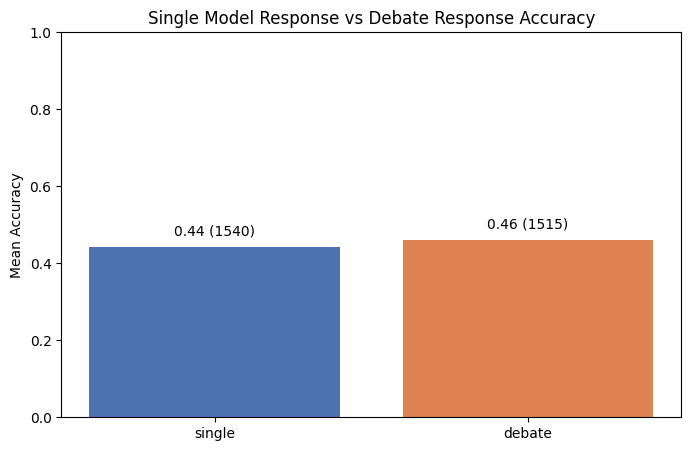

Saved evaluation prompt/results to: biography_evaluation_results2.json


In [29]:
summary = {}
for stage, values in accuracies_by_stage.items():
    summary[stage] = {
        "count": len(values),
        "mean_accuracy": float(np.mean(values)) if values else None,
        "standard_error": float(np.std(values) / (len(values) ** 0.5)) if len(values) > 0 else None,
    }

if any(summary[s]["count"] > 0 for s in summary):
    print("================================================")
    print("FINAL EVALUATION")
    print("================================================")
    for stage, stats in summary.items():
        print(f"{stage.title()} Mean Accuracy: {stats['mean_accuracy']}")
        print(f"{stage.title()} Standard Error: {stats['standard_error']}")
else:
    print("No valid evaluation results")

# Plot accuracy comparison
stages = ["single", "debate"]
means = [summary[s]["mean_accuracy"] or 0 for s in stages]
counts = [summary[s]["count"] for s in stages]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(stages, means, color=["#4C72B0", "#DD8452"])
ax.set_ylim(0, 1)
ax.set_ylabel("Mean Accuracy")
ax.set_title("Single Model Response vs Debate Response Accuracy")
for i, (mean_val, count) in enumerate(zip(means, counts)):
    ax.text(i, mean_val + 0.03, f"{mean_val:.2f} ({count})", ha="center")
plt.show()

# Save evaluation prompts and results
with open(EVAL_OUTPUT_FILE, "w") as f:
    json.dump({"summary": summary, "records": evaluation_records}, f, indent=2)

print("Saved evaluation prompt/results to:", EVAL_OUTPUT_FILE)